In [1]:
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# 1. Load Data

In [2]:
df = pd.read_csv(r"../data/Crop_recommendation.csv")
df = df.drop(columns=[c for c in df.columns if c.lower().startswith('unnamed')])
df.columns = df.columns.str.lower()

In [3]:
X = df.drop('label', axis=1)
y = df['label']

In [4]:
scaler = joblib.load("../models/scaler.pkl")
selected_features = joblib.load("../models/selected_features.pkl")

In [10]:
X = X[scaler.feature_names_in_]
X_scaled = scaler.transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Load Best Model (Assuming RandomForest won based on Day 4 metrics)

In [12]:
best_model = joblib.load("../models/RandomForest.pkl")
y_pred = best_model.predict(X_test)

# 3. Plot Confusion Matrix w/ Labels

In [13]:
cm = confusion_matrix(y_test, y_pred)
labels = sorted(y.unique())
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

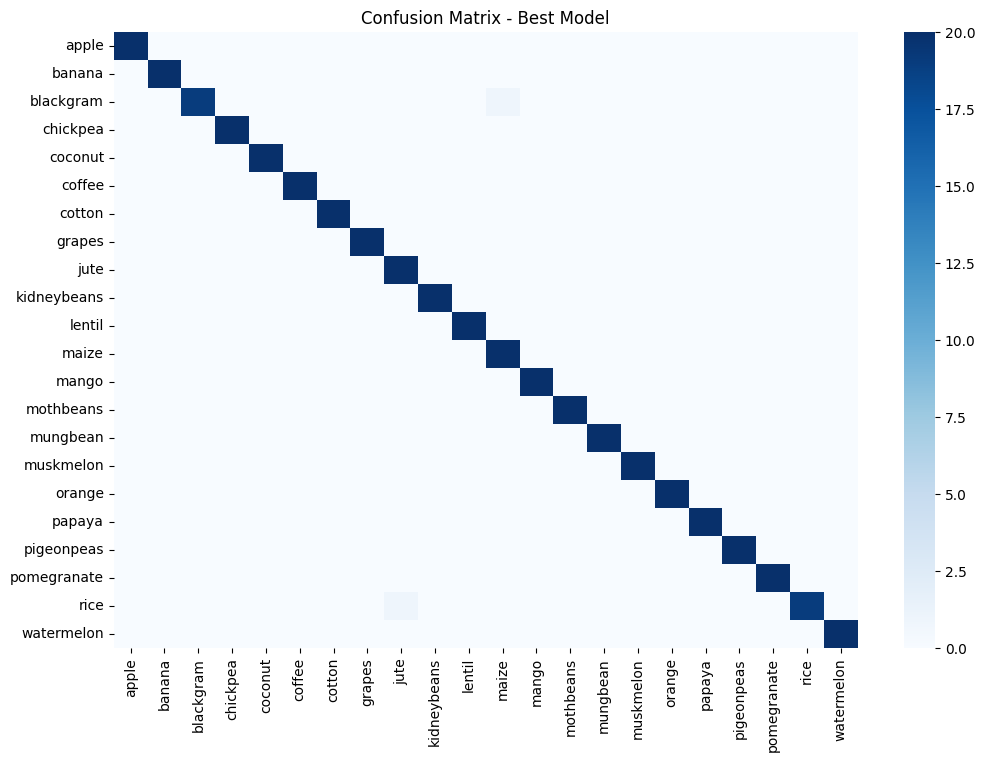

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(cm_df, cmap='Blues')
plt.title("Confusion Matrix - Best Model")
plt.show()

# 4. Interpretability: Feature Importance Plot

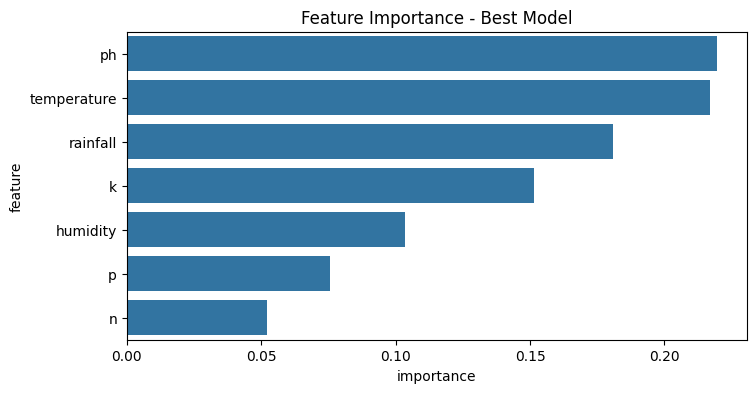

In [18]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    fi_df = pd.DataFrame({
        "feature": selected_features,
        "importance": importances
    }).sort_values(by="importance", ascending=False)
    
    plt.figure(figsize=(8,4))
    sns.barplot(data=fi_df, x="importance", y="feature")
    plt.title("Feature Importance - Best Model")
    plt.show()